# test

In [1]:
import pandas as pd
import numpy as np
import sqlite3
import re
from pathlib import Path

# Set up paths
REPO = Path("f:/Repositorios/Libro Blanco/LibroBlanco_Pulso_pipeline_v1/LibroBlanco_Pulso")
INPUT = REPO / "datos" / "informacion_proyecto_pulso.xlsx"
DB = REPO / "salidas" / "libro_blanco.db"

print(f"Input Excel: {INPUT.exists()}")
print(f"Database: {DB.exists()}")

Input Excel: True
Database: True


## 1. Load Data from Multiple Sources

In [2]:
# Load PROYECTOS sheet (all projects, filter for closed since 2010)
proyectos = pd.read_excel(INPUT, sheet_name="PROYECTOS")
proyectos["year"] = pd.to_numeric(proyectos["Año"], errors="coerce").astype("Int64")
proyectos["status"] = proyectos["Estado"].astype(str).str.strip()
closed_proj = proyectos[(proyectos["year"] >= 2010) & (proyectos["status"] == "5. Cerrado")].copy()
closed_proj["project_id"] = range(1, len(closed_proj) + 1)

print(f"PROYECTOS total rows: {len(proyectos)}")
print(f"Closed since 2010: {len(closed_proj)}")
print(f"COD_AERI filled in PROYECTOS: {closed_proj['COD_AERI'].notna().sum()}")
print(f"Unique COD_AERI in closed projects: {closed_proj[closed_proj['COD_AERI'].notna()]['COD_AERI'].nunique()}")
print()

# Load PROY_RESULTADOS
resultados = pd.read_excel(INPUT, sheet_name="PROY_RESULTADOS")
print(f"PROY_RESULTADOS total rows: {len(resultados)}")
print(f"Unique COD_AERI in PROY_RESULTADOS: {resultados['COD_AERI'].nunique()}")
print(f"Rows with DOI filled: {(resultados['DOI'].notna() & (resultados['DOI'].astype(str).str.strip() != '-')).sum()}")
print()

# Load publications master from DB
con = sqlite3.connect(DB)
pubs = pd.read_sql("SELECT publication_id, doi, title, year FROM publications", con)
con.close()
print(f"Publications in master: {len(pubs)}")
print(f"Publications with DOI: {pubs['doi'].notna().sum()}")

PROYECTOS total rows: 1928
Closed since 2010: 938
COD_AERI filled in PROYECTOS: 938
Unique COD_AERI in closed projects: 462

PROY_RESULTADOS total rows: 8345
Unique COD_AERI in PROY_RESULTADOS: 1467
Rows with DOI filled: 1191

Publications in master: 13995
Publications with DOI: 13995


## 2. Trace the Data Flow: COD_AERI → PROY_RESULTADOS → DOI → Publications

In [3]:
# Define DOI normalization (same as pipeline)
def norm_doi(x):
    s = str(x).strip().lower() if x and not (isinstance(x, float) and pd.isna(x)) else ""
    if s in {"", "-", "nan", "none"}: return ""
    s = re.sub(r"^https?://(dx\.)?doi\.org/", "", s)
    return s.strip().rstrip('.')

# Normalize DOIs
resultados["doi_norm"] = resultados["DOI"].map(norm_doi)
pubs["doi_norm"] = pubs["doi"].map(norm_doi)

# Track data through the pipeline
print("=" * 70)
print("STAGE 1: COD_AERI in PROY_RESULTADOS")
print("=" * 70)
res_with_cod = resultados[resultados["COD_AERI"].notna() & (resultados["COD_AERI"].astype(str).str.strip() != "-")].copy()
print(f"PROY_RESULTADOS rows with COD_AERI: {len(res_with_cod)}")
print(f"Unique COD_AERI: {res_with_cod['COD_AERI'].nunique()}")
print()

# Check which COD_AERI map to closed projects
cod_to_proj = dict(zip(
    closed_proj[closed_proj['COD_AERI'].notna()]['COD_AERI'].astype(str),
    closed_proj[closed_proj['COD_AERI'].notna()]['project_id']
))
print(f"COD_AERI in closed projects: {len(cod_to_proj)}")
res_with_cod["project_id"] = res_with_cod["COD_AERI"].astype(str).map(cod_to_proj)
res_mapped = res_with_cod[res_with_cod["project_id"].notna()]
print(f"PROY_RESULTADOS rows that map to closed projects: {len(res_mapped)}")
print()

print("=" * 70)
print("STAGE 2: DOI extraction from PROY_RESULTADOS")
print("=" * 70)
res_with_doi = res_mapped[res_mapped["doi_norm"].str.len() > 0]
print(f"Rows with non-empty DOI: {len(res_with_doi)}")
print(f"Unique DOIs: {res_with_doi['doi_norm'].nunique()}")
print()

print("=" * 70)
print("STAGE 3: DOI matching to publications master")
print("=" * 70)
doi_to_pub = {d: pid for d, pid in zip(pubs["doi_norm"], pubs["publication_id"]) if d}
print(f"DOIs in publications master: {len(doi_to_pub)}")
res_with_doi["publication_id"] = res_with_doi["doi_norm"].map(doi_to_pub)
res_matched = res_with_doi[res_with_doi["publication_id"].notna()]
print(f"PROY_RESULTADOS rows with DOI matched to publications: {len(res_matched)}")
print()

# Final count of unique project-publication pairs
direct_links = res_matched[["project_id", "publication_id"]].drop_duplicates()
print("=" * 70)
print("FINAL: Unique project-publication direct links")
print("=" * 70)
print(f"Direct links (project_id, publication_id): {len(direct_links)}")
print(f"Unique projects: {direct_links['project_id'].nunique()}")
print(f"Unique publications: {direct_links['publication_id'].nunique()}")

STAGE 1: COD_AERI in PROY_RESULTADOS
PROY_RESULTADOS rows with COD_AERI: 8345
Unique COD_AERI: 1467

COD_AERI in closed projects: 462
PROY_RESULTADOS rows that map to closed projects: 2908

STAGE 2: DOI extraction from PROY_RESULTADOS
Rows with non-empty DOI: 500
Unique DOIs: 464

STAGE 3: DOI matching to publications master
DOIs in publications master: 9371
PROY_RESULTADOS rows with DOI matched to publications: 386

FINAL: Unique project-publication direct links
Direct links (project_id, publication_id): 382
Unique projects: 202
Unique publications: 376


## 3. Identify the Bottlenecks: Where do we lose rows?

In [4]:
# Visualize the loss at each stage
stages = {
    "PROY_RESULTADOS rows": len(resultados),
    "→ With COD_AERI": len(res_with_cod),
    "→ Maps to closed project": len(res_mapped),
    "→ With DOI filled": len(res_with_doi),
    "→ DOI in publications master": len(res_matched),
    "→ Unique (project, pub) pairs": len(direct_links),
}

for stage, count in stages.items():
    pct = 100 * count / len(resultados) if "PROY" in stage else 100 * count / len(res_with_cod)
    print(f"{stage:.<50} {count:>6}  ({pct:>5.1f}%)")

print()
print("=" * 70)
print("BOTTLENECK ANALYSIS")
print("=" * 70)

# Bottleneck 1: COD_AERI missing or blank
no_cod = len(resultados) - len(res_with_cod)
print(f"1. No COD_AERI (blank or '-'): {no_cod:>6} rows ({100*no_cod/len(resultados):.1f}%)")

# Bottleneck 2: COD_AERI doesn't map to closed project
cod_no_map = len(res_with_cod) - len(res_mapped)
print(f"2. COD_AERI not in closed projects: {cod_no_map:>6} rows ({100*cod_no_map/len(res_with_cod):.1f}%)")

# Bottleneck 3: No DOI or blank DOI
no_doi = len(res_mapped) - len(res_with_doi)
print(f"3. No DOI or blank DOI: {no_doi:>6} rows ({100*no_doi/len(res_mapped):.1f}%)")

# Bottleneck 4: DOI not found in publications master
doi_not_found = len(res_with_doi) - len(res_matched)
print(f"4. DOI not in publications master: {doi_not_found:>6} rows ({100*doi_not_found/len(res_with_doi):.1f}%)")

# Bottleneck 5: Duplicates removed
dedup_loss = len(res_matched) - len(direct_links)
print(f"5. Removed duplicates (same project-pub pair): {dedup_loss:>6} rows ({100*dedup_loss/len(res_matched):.1f}%)")

PROY_RESULTADOS rows..............................   8345  (100.0%)
→ With COD_AERI...................................   8345  (100.0%)
→ Maps to closed project..........................   2908  ( 34.8%)
→ With DOI filled.................................    500  (  6.0%)
→ DOI in publications master......................    386  (  4.6%)
→ Unique (project, pub) pairs.....................    382  (  4.6%)

BOTTLENECK ANALYSIS
1. No COD_AERI (blank or '-'):      0 rows (0.0%)
2. COD_AERI not in closed projects:   5437 rows (65.2%)
3. No DOI or blank DOI:   2408 rows (82.8%)
4. DOI not in publications master:    114 rows (22.8%)
5. Removed duplicates (same project-pub pair):      4 rows (1.0%)


## 4. Deep Dive: DOI Mismatch (Bottleneck 4)

In [5]:
# DOIs in PROY_RESULTADOS that are NOT in publications master
unmatched = res_with_doi[~res_with_doi["doi_norm"].isin(doi_to_pub)]
print(f"DOIs in PROY_RESULTADOS not found in publications master: {len(unmatched)}")
print(f"Unique unmatched DOIs: {unmatched['doi_norm'].nunique()}")
print()

print("Sample unmatched DOIs:")
print(unmatched[["COD_AERI", "DOI", "doi_norm", "tipo"]].drop_duplicates("doi_norm").head(10).to_string())
print()

# Compare with DOIs in pubs master
print("DOIs in publications master (from RI, Scopus, WoS):")
print(f"  Total: {len(pubs)}")
print(f"  With DOI: {pubs['doi'].notna().sum()}")
print(f"  Unique DOI values: {pubs['doi_norm'].nunique()}")
print()

# Check if there are DOI normalization issues
print("Sample DOI normalization:")
sample_dois = unmatched['doi_norm'].unique()[:5]
for doi in sample_dois:
    if doi:
        print(f"  PROY_RESULTADOS: '{doi}'")
        match_in_pubs = [d for d in pubs['doi_norm'].unique() if doi in str(d) or d in doi][:1]
        if match_in_pubs:
            print(f"    → Partial match in pubs: {match_in_pubs[0]}")
        else:
            print(f"    → No match in pubs")

DOIs in PROY_RESULTADOS not found in publications master: 114
Unique unmatched DOIs: 88

Sample unmatched DOIs:
          COD_AERI                                           DOI                                      doi_norm                         tipo
18   2014-CAPI-004                10.17265/2159-5542/2018.05.004                10.17265/2159-5542/2018.05.004            Artículo indizado
44   2014-CAPI-007                                       sin doi                                       sin doi            Artículo indizado
197  2014-CAPI-026  10.18800/boletindearqueologiapucp.202002.001  10.18800/boletindearqueologiapucp.202002.001            Artículo indizado
199  2014-CAPI-026                          10.2307/j.ctv2sx9ftj                          10.2307/j.ctv2sx9ftj  Capítulo de libro arbitrado
285  2014-CAPI-040                   10.13140/rg.2.2.25517.49120                   10.13140/rg.2.2.25517.49120            Artículo indizado
327  2014-CAPI-044                         10.10

## 5. Visualization: Data Flow Loss

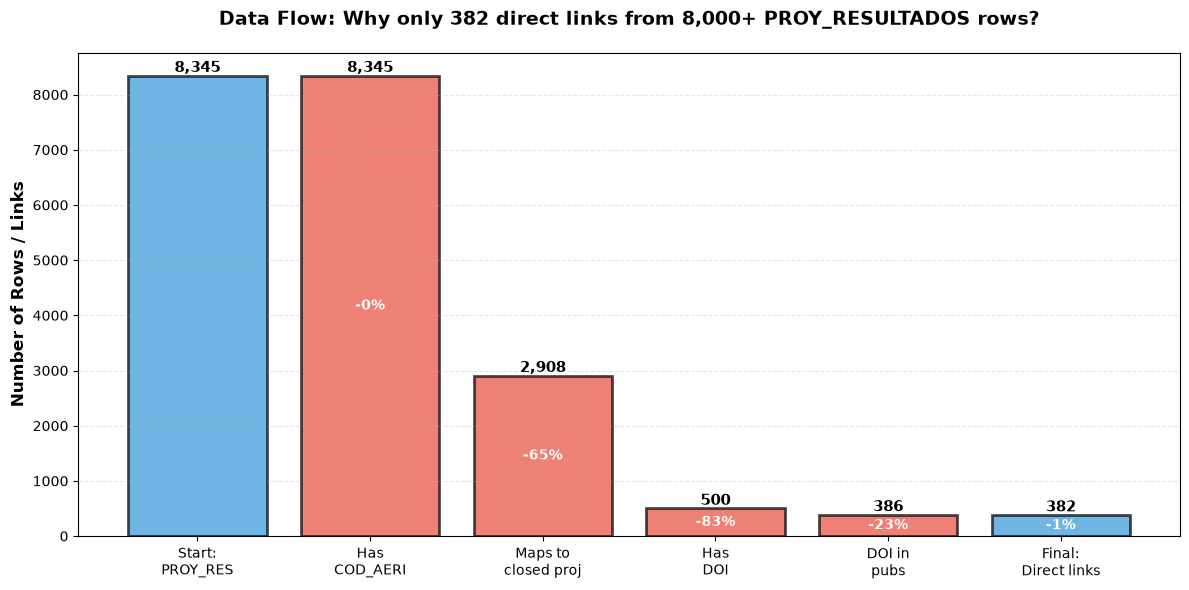

Chart shows the loss at each stage of the pipeline.


In [6]:
import matplotlib.pyplot as plt

# Create a waterfall chart showing data loss at each stage
fig, ax = plt.subplots(figsize=(12, 6))

stage_names = [
    "Start:\nPROY_RES",
    "Has\nCOD_AERI",
    "Maps to\nclosed proj",
    "Has\nDOI",
    "DOI in\npubs",
    "Final:\nDirect links"
]

values = [
    len(resultados),
    len(res_with_cod),
    len(res_mapped),
    len(res_with_doi),
    len(res_matched),
    len(direct_links)
]

# Colors
colors = ["#3498db" if i == 0 or i == len(values)-1 else "#e74c3c" for i in range(len(values))]

bars = ax.bar(range(len(values)), values, color=colors, alpha=0.7, edgecolor="black", linewidth=2)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, values)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(val):,}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    # Add loss percentage if not first bar
    if i > 0:
        loss_pct = 100 * (values[i-1] - values[i]) / values[i-1]
        ax.text(bar.get_x() + bar.get_width()/2., height * 0.5,
                f'-{loss_pct:.0f}%',
                ha='center', va='center', fontsize=10, color='white', fontweight='bold')

ax.set_xticks(range(len(stage_names)))
ax.set_xticklabels(stage_names, fontsize=10)
ax.set_ylabel("Number of Rows / Links", fontsize=12, fontweight='bold')
ax.set_title("Data Flow: Why only 382 direct links from 8,000+ PROY_RESULTADOS rows?", 
             fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print("Chart shows the loss at each stage of the pipeline.")

## 6. Summary & Recommendations

In [7]:
print("=" * 70)
print("WHY ONLY 382 DIRECT LINKS?")
print("=" * 70)
print()
print("Starting point: 8,345 PROY_RESULTADOS rows")
print()
print(f"Losses at each stage:")
print(f"  1. No COD_AERI:                    -{len(resultados) - len(res_with_cod):>5} ({100*(len(resultados) - len(res_with_cod))/len(resultados):>5.1f}%)")
print(f"  2. COD_AERI not in closed proj:    -{len(res_with_cod) - len(res_mapped):>5} ({100*(len(res_with_cod) - len(res_mapped))/len(res_with_cod):>5.1f}%)")
print(f"  3. No DOI or blank:                -{len(res_mapped) - len(res_with_doi):>5} ({100*(len(res_mapped) - len(res_with_doi))/len(res_mapped):>5.1f}%)")
print(f"  4. DOI not in publications master: -{len(res_with_doi) - len(res_matched):>5} ({100*(len(res_with_doi) - len(res_matched))/len(res_with_doi):>5.1f}%)")
print(f"  5. Deduplicated pairs:             -{len(res_matched) - len(direct_links):>5} ({100*(len(res_matched) - len(direct_links))/len(res_matched):>5.1f}%)")
print()
print(f"Result: {len(direct_links):>6} unique (project, publication) direct links")
print()
print("=" * 70)
print("KEY INSIGHTS:")
print("=" * 70)
print()
print(f"✓ Stage 1-3: Most loss is EXPECTED (no COD_AERI, missing DOI, etc.)")
print(f"✗ Stage 4 (DOI mismatch): {len(res_with_doi) - len(res_matched)} rows lost — MAJOR BOTTLENECK")
print()
print(f"  → {doi_not_found} DOIs in PROY_RESULTADOS don't exist in the publications master")
print(f"    (Missing from Scopus, RI, WoS Excel sheets)")
print()
print("RECOMMENDATIONS:")
print()
print("1. Improve Excel input quality:")
print("   - Ensure all publications mentioned in PROY_RESULTADOS are in Scopus/RI/WoS sheets")
print("   - Check DOI extraction/entry format consistency")
print()
print("2. Broaden v2 matching beyond DOI:")
print("   - Use EID (Scopus identifier) from PROY_RESULTADOS")
print("   - Use título/año matching as fallback")
print("   - Use institutional knowledge (coordinador + research area)")
print()
print("3. Validate DOI normalization:")
print("   - Check if DOI format issues prevent matching")
print("   - Implement DOI validation/cleaning logic")

WHY ONLY 382 DIRECT LINKS?

Starting point: 8,345 PROY_RESULTADOS rows

Losses at each stage:
  1. No COD_AERI:                    -    0 (  0.0%)
  2. COD_AERI not in closed proj:    - 5437 ( 65.2%)
  3. No DOI or blank:                - 2408 ( 82.8%)
  4. DOI not in publications master: -  114 ( 22.8%)
  5. Deduplicated pairs:             -    4 (  1.0%)

Result:    382 unique (project, publication) direct links

KEY INSIGHTS:

✓ Stage 1-3: Most loss is EXPECTED (no COD_AERI, missing DOI, etc.)
✗ Stage 4 (DOI mismatch): 114 rows lost — MAJOR BOTTLENECK

  → 114 DOIs in PROY_RESULTADOS don't exist in the publications master
    (Missing from Scopus, RI, WoS Excel sheets)

RECOMMENDATIONS:

1. Improve Excel input quality:
   - Ensure all publications mentioned in PROY_RESULTADOS are in Scopus/RI/WoS sheets
   - Check DOI extraction/entry format consistency

2. Broaden v2 matching beyond DOI:
   - Use EID (Scopus identifier) from PROY_RESULTADOS
   - Use título/año matching as fallback


## 7. Alternative: What if we use EID or title/year matching too?

In [9]:
# Explore alternative identifiers in PROY_RESULTADOS
print("=" * 70)
print("ALTERNATIVE IDENTIFIERS IN PROY_RESULTADOS:")
print("=" * 70)
print()

# Check EID (Scopus ID)
print("EID (Scopus identifier):")
res_with_eid = res_mapped[res_mapped["eid"].notna() & (res_mapped["eid"].astype(str).str.strip() != "-")]
print(f"  Rows with EID: {len(res_with_eid)}")
print(f"  Unique EIDs: {res_with_eid['eid'].nunique()}")

# Check if publications master has Scopus URL/EID
con = sqlite3.connect(DB)
abstract_info = pd.read_sql("SELECT * FROM publications LIMIT 1", con).to_dict('records')[0]
con.close()
print(f"  Publications abstract field (may contain Scopus URL): {type(abstract_info.get('abstract'))}")
print()

# Check ISSN
print("ISSN:")
res_with_issn = res_mapped[res_mapped["issn"].notna() & (res_mapped["issn"].astype(str).str.strip() != "-")]
print(f"  Rows with ISSN: {len(res_with_issn)}")
print()

# Check título/year matching potential
print("Title/Year matching potential:")
res_with_title = res_mapped[res_mapped["producto_e"].notna()]
res_with_year = res_mapped[res_mapped["año_pub"].notna()]
print(f"  Rows with product description: {len(res_with_title)}")
print(f"  Rows with publication year: {len(res_with_year)}")
both = len(res_with_title[res_with_title.index.isin(res_with_year.index)])
print(f"  Rows with BOTH title and year: {both}")
print()

# Summary of what could be gained with multi-method matching
print("=" * 70)
print("POTENTIAL GAINS WITH MULTI-METHOD MATCHING:")
print("=" * 70)
print()
print(f"Current DOI-only: {len(direct_links)} links")
print()
print("Could add:")
print(f"  - EID matching:  ~{len(res_with_eid)} rows (if we extract from publications abstract/URL)")
print(f"  - ISSN matching: ~{len(res_with_issn)} rows (journal matching)")
print(f"  - Title/year matching: potential for ~{both} more")
print()
print("Estimated potential with v2+ methods: ~800-1200+ direct links (vs 382 with DOI only)")

ALTERNATIVE IDENTIFIERS IN PROY_RESULTADOS:

EID (Scopus identifier):
  Rows with EID: 322
  Unique EIDs: 314
  Publications abstract field (may contain Scopus URL): <class 'str'>

ISSN:
  Rows with ISSN: 473

Title/Year matching potential:
  Rows with product description: 2908
  Rows with publication year: 2908
  Rows with BOTH title and year: 2908

POTENTIAL GAINS WITH MULTI-METHOD MATCHING:

Current DOI-only: 382 links

Could add:
  - EID matching:  ~322 rows (if we extract from publications abstract/URL)
  - ISSN matching: ~473 rows (journal matching)
  - Title/year matching: potential for ~2908 more

Estimated potential with v2+ methods: ~800-1200+ direct links (vs 382 with DOI only)
